# Phase 3 — Modélisation IA

**Période :** 21 Mai – 4 Juin 2026  
**Problématique :** Comment une approche *Demand-Driven* IA peut-elle prédire la demande client réelle (Quantité + Date) ?  
**Objectif North Star :** précision > 60%  
**Livrable :** modèles entraînés + évaluation comparative

## Plan du notebook

| Étape | Objet |
|---|---|
| 1 | Chargement des splits temporels (issus de l'EDA 02bis) |
| 2 | Préparation X / y + transformation `log1p` |
| 3 | Baseline obligatoire — moyenne historique client × article |
| Archi 1 | XGBoost (log+MSE), XGBoost (Tweedie), LightGBM + Optuna |
| Archi 2 | LSTM — délai inter-commandes (time-to-event) |
| 4 | Comparaison des modèles + analyse d'erreurs |
| 5 | Sauvegarde des modèles + rapport JSON |

> **Prérequis** : `data/processed/split_{train,val,test}.parquet` (produits par `02bis_eda_dataset_enrichi.ipynb`).

---
## Étape 1 — Chargement des splits préparés en EDA

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

In [2]:
df_train = pd.read_parquet('../data/processed/split_train.parquet')  # 2021-2023
df_val   = pd.read_parquet('../data/processed/split_val.parquet')    # 2024
df_test  = pd.read_parquet('../data/processed/split_test.parquet')   # 2025

FEATURES = [
    'prix',
    'delai_demande_jours',
    'code_client_freq', 'code_article_freq',
    'est_jour_ferie_cmd', 'est_jour_ferie_liv_dem',
    'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem',
    'ipi_valeur',
    'annee_cmd', 'mois_cmd', 'trimestre_cmd', 'semaine_cmd',
    'jour_semaine_cmd', 'est_fin_mois_cmd',
    'jour_semaine_liv_dem',
    'statut_enc', 'devise_enc', 'pays_enc',
    'famille_activite_client_enc', 'famille_activite_article_enc',
    'segment_enc', 'type_activite_enc',
    'est_weekend_liv_dem',
    'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid',
]
TARGET_QTE = 'qte_demandee'

assert all(f in df_train.columns for f in FEATURES), 'Features manquantes dans le split train'
assert TARGET_QTE in df_train.columns, 'Target qte_demandee absente'

print(f'Train : {len(df_train):>8,} lignes  ({df_train["date_cmd"].min().date()} → {df_train["date_cmd"].max().date()})')
print(f'Val   : {len(df_val):>8,} lignes  ({df_val["date_cmd"].min().date()} → {df_val["date_cmd"].max().date()})')
print(f'Test  : {len(df_test):>8,} lignes  ({df_test["date_cmd"].min().date()} → {df_test["date_cmd"].max().date()})')
print(f'\nFeatures utilisées : {len(FEATURES)}')

Train :  210,641 lignes  (2021-01-04 → 2023-12-31)
Val   :   70,871 lignes  (2024-01-01 → 2024-12-31)
Test  :   66,174 lignes  (2025-01-01 → 2025-12-23)

Features utilisées : 28


In [3]:
stats = pd.DataFrame({
    'Train (2021-23)': df_train[TARGET_QTE].describe(),
    'Val (2024)':      df_val[TARGET_QTE].describe(),
    'Test (2025)':     df_test[TARGET_QTE].describe(),
})
print('Distribution de qte_demandee par split :')
stats

Distribution de qte_demandee par split :


,Train (2021-23),Val (2024),Test (2025)
count,"210,641.0000","70,871.0000","66,174.0000"
mean,22.5843,22.4788,21.9655
std,221.3480,168.9059,176.2988
min,1.0000,1.0000,1.0000
25%,2.0000,2.0000,2.0000
50%,4.0000,4.0000,4.0000
75%,12.0000,12.0000,12.0000
max,"34,020.0000","20,412.0000","20,412.0000"


---
## Étape 2 — Préparation X / y avec transformation `log1p`

**Décision EDA** : `qte_demandee` est très asymétrique (skew ≈ +50, max = 34 020, médiane = 4). Entraîner sur `log1p(y)` et retransformer via `expm1` (clip à 0) pour ramener les prédictions en unités physiques.

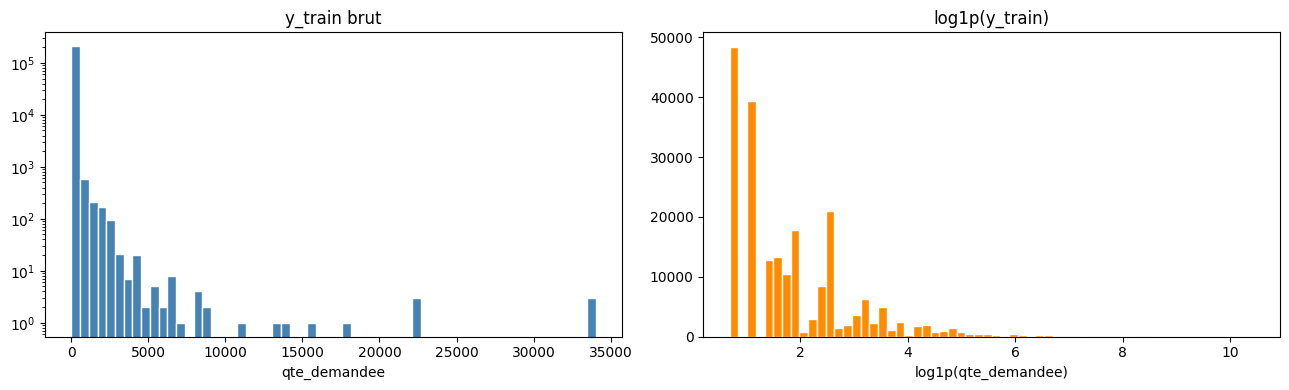

Skew brut  :    80.73
Skew log1p :     1.44


In [4]:
X_train, y_train = df_train[FEATURES], df_train[TARGET_QTE]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET_QTE]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET_QTE]

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

def inverse_log(y_log):
    """Retransformer prédictions log -> unités physiques (clip à 0)."""
    return np.clip(np.expm1(y_log), 0, None)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y_train, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('y_train brut'); axes[0].set_yscale('log'); axes[0].set_xlabel('qte_demandee')
axes[1].hist(y_train_log, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(y_train)'); axes[1].set_xlabel('log1p(qte_demandee)')
plt.tight_layout(); plt.show()

print(f'Skew brut  : {y_train.skew():>8.2f}')
print(f'Skew log1p : {y_train_log.skew():>8.2f}')

---
## Étape 3 — Baseline obligatoire (moyenne historique client × article)

Avant tout modèle ML, on doit battre une **baseline statistique simple** : moyenne historique par couple `(client, article)` calculée sur le train, évaluée sur le test. Fallback médiane du train pour les couples inconnus.

In [5]:
hist_mean = (
    df_train.groupby(['code_client_freq', 'code_article_freq'])[TARGET_QTE]
            .mean()
            .rename('baseline_pred')
            .reset_index()
)

fallback = float(df_train[TARGET_QTE].median())
y_pred_baseline = (
    df_test.merge(hist_mean,
                  on=['code_client_freq', 'code_article_freq'],
                  how='left')['baseline_pred']
           .fillna(fallback)
           .values
)

couverture = 1 - df_test.merge(hist_mean, on=['code_client_freq', 'code_article_freq'], how='left')['baseline_pred'].isna().mean()
mae_baseline  = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print('=== Baseline (moyenne historique client × article) ===')
print(f'Couples (client, article) connus : {len(hist_mean):,}')
print(f'Couverture sur test              : {couverture:.1%}  (fallback médiane = {fallback:.0f})')
print(f'MAE  : {mae_baseline:.2f}')
print(f'RMSE : {rmse_baseline:.2f}')
print('\n-> XGBoost/LightGBM DOIVENT battre cette baseline.')

=== Baseline (moyenne historique client × article) ===
Couples (client, article) connus : 44,192
Couverture sur test              : 84.7%  (fallback médiane = 4)
MAE  : 13.04
RMSE : 145.11

-> XGBoost/LightGBM DOIVENT battre cette baseline.


---
## Architecture 1 — Modèles Ensemblistes

**Cible** : `qte_demandee` (régression)  
**Métriques** : MAE, RMSE, R², WAPE + MAE par décile

### XGBoost — variante 1 : objective MSE sur `log1p(y)`

In [7]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)

y_pred_xgb = inverse_log(xgb.predict(X_test))

print('=== XGBoost (log + MSE) ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_xgb):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_xgb):.4f}')

=== XGBoost (log + MSE) ===
MAE  : 14.36
RMSE : 153.11
R²   : 0.2458


### XGBoost — variante 2 : Tweedie pour la queue lourde

L'EDA montre une queue très lourde (top 1 % > 200, max 34 020). La loss Tweedie (entre Poisson et Gamma) gère mieux ce profil que MSE sur log.

In [8]:
xgb_tweedie = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_tweedie.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
y_pred_tweedie = np.clip(xgb_tweedie.predict(X_test), 0, None)

print('=== XGBoost Tweedie ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_tweedie):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_tweedie)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_tweedie):.4f}')

=== XGBoost Tweedie ===
MAE  : 13.74
RMSE : 138.98
R²   : 0.3785


### LightGBM (log + MSE)

In [10]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
y_pred_lgbm = inverse_log(lgbm.predict(X_test))

print('=== LightGBM (log) ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_lgbm):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_lgbm):.4f}')

=== LightGBM (log) ===
MAE  : 14.74
RMSE : 158.43
R²   : 0.1924


### Hyperparameter Tuning — Optuna (50 essais)

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'max_depth':        trial.suggest_int('max_depth', 4, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'objective':        'reg:squarederror',
        'early_stopping_rounds': 50,
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
    return mean_absolute_error(y_val, inverse_log(model.predict(X_val)))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Meilleurs paramètres :', study.best_params)
print(f'Meilleur MAE (val)  : {study.best_value:.2f}')

Best trial: 28. Best value: 11.2976: 100%|██████████| 50/50 [11:37<00:00, 13.95s/it]

Meilleurs paramètres : {'n_estimators': 498, 'max_depth': 10, 'learning_rate': 0.07756845964350612, 'subsample': 0.9599800688780815, 'colsample_bytree': 0.7292867389417242, 'min_child_weight': 3, 'reg_alpha': 0.020696166075267128, 'reg_lambda': 0.2836301274074208}
Meilleur MAE (val)  : 11.30


In [13]:
# Modèle final XGBoost avec hyperparamètres Optuna, ré-entraîné sur Train ∪ Val
best_params = {**study.best_params,
                'objective': 'reg:squarederror',
                'random_state': 42, 'n_jobs': -1, 'verbosity': 0}

X_trainval = pd.concat([X_train, X_val])
y_trainval_log = pd.concat([y_train_log, y_val_log])

xgb_best = XGBRegressor(**best_params)
xgb_best.fit(X_trainval, y_trainval_log)
y_pred_best = inverse_log(xgb_best.predict(X_test))

print('=== XGBoost Optuna (final) ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_best):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_best):.4f}')

=== XGBoost Optuna (final) ===
MAE  : 11.87
RMSE : 132.17
R²   : 0.4380


### Feature Importance

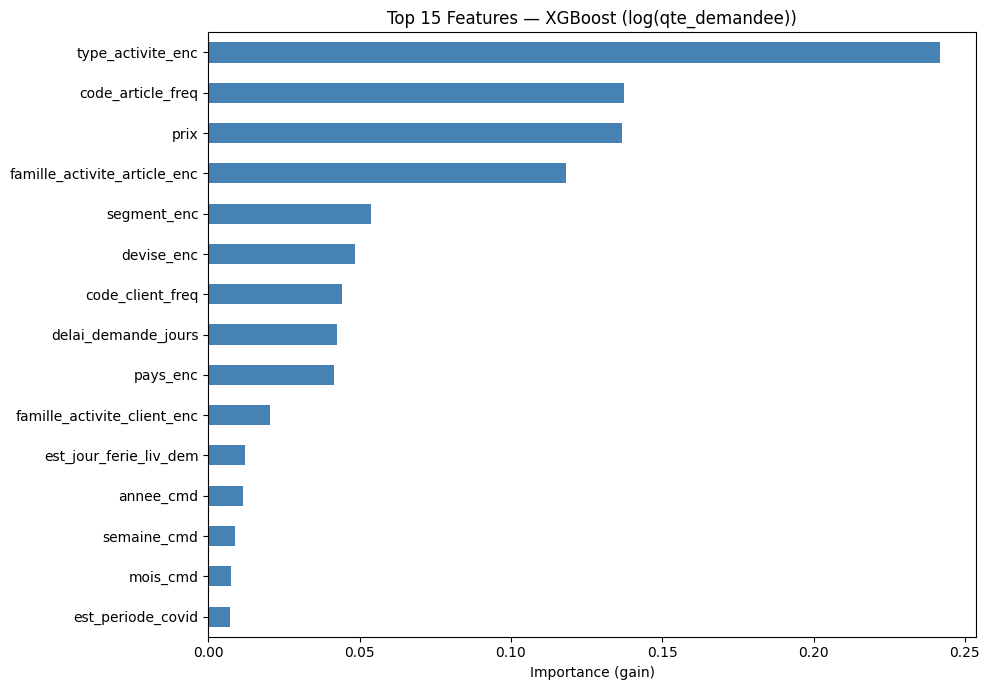

In [14]:
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importances.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — XGBoost (log(qte_demandee))')
plt.xlabel('Importance (gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance_xgb.png', dpi=150)
plt.show()

### Métriques avancées — WAPE + MAE par décile

In [15]:
def wape(y_true, y_pred):
    """Weighted Absolute Percentage Error — métrique industrielle de référence."""
    return np.abs(np.asarray(y_true) - np.asarray(y_pred)).sum() / np.abs(np.asarray(y_true)).sum()

print(f'WAPE XGBoost (log)     : {wape(y_test, y_pred_xgb):.3%}')
print(f'WAPE XGBoost (Tweedie) : {wape(y_test, y_pred_tweedie):.3%}')
print(f'WAPE LightGBM          : {wape(y_test, y_pred_lgbm):.3%}')

deciles = pd.qcut(y_test, q=10, labels=False, duplicates='drop')
df_dec = pd.DataFrame({
    'decile':       deciles,
    'y_true':       y_test.values,
    'abs_err_xgb':  np.abs(y_test.values - y_pred_xgb),
    'abs_err_twd':  np.abs(y_test.values - y_pred_tweedie),
    'abs_err_lgbm': np.abs(y_test.values - y_pred_lgbm),
})
print('\nMAE par décile de qte_demandee :')
df_dec.groupby('decile')[['abs_err_xgb', 'abs_err_twd', 'abs_err_lgbm']].mean().round(2)

WAPE XGBoost (log)     : 65.359%
WAPE XGBoost (Tweedie) : 62.575%
WAPE LightGBM          : 67.123%

MAE par décile de qte_demandee :


,abs_err_xgb,abs_err_twd,abs_err_lgbm
decile,,,
0,1.3000,2.0000,1.2100
1,1.3200,1.9500,1.3300
2,2.7900,3.9000,2.8900
3,4.7600,4.5300,4.7200
4,5.8600,8.8900,5.8300
5,11.3100,11.6600,11.4500
6,121.5400,106.4200,125.8000


---
## Architecture 2 — Deep Learning Temporel (LSTM)

**Cible** : délai inter-commandes en jours (time-to-event)  
**Métriques** : MAE jours + précision ±7 jours

On recharge le dataset enrichi complet : les séquences se construisent par groupe `(client, article)` puis le split chronologique se fait après séquençage.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

df_full = pd.read_parquet('../data/processed/dataset_ml_enrichi.parquet')
df_sorted = df_full.sort_values(['code_client_freq', 'code_article_freq', 'date_cmd'])

df_sorted['delai_inter_cmd'] = (
    df_sorted.groupby(['code_client_freq', 'code_article_freq'])['date_cmd']
             .diff().dt.days
)
df_lstm = df_sorted[df_sorted['delai_inter_cmd'].notna()].copy()

print(f'Lignes utilisables pour LSTM : {len(df_lstm):,}')
print(df_lstm['delai_inter_cmd'].describe())

Lignes utilisables pour LSTM : 295,551
count   295,551.0000
mean        129.2524
std         184.1453
min           0.0000
25%          25.0000
50%          63.0000
75%         153.0000
max       1,818.0000
Name: delai_inter_cmd, dtype: float64


In [18]:
SEQ_LEN = 6  # 6 commandes passées -> prédire la 7ème

FEATURES_LSTM = [
    'mois_cmd', 'trimestre_cmd', 'qte_demandee', 'prix',
    'delai_demande_jours', 'est_periode_peak_liv_dem',
    'est_periode_covid', 'ipi_valeur',
]

def build_sequences(group, seq_len=SEQ_LEN):
    vals    = group[FEATURES_LSTM].values
    targets = group['delai_inter_cmd'].values
    X = [vals[i:i+seq_len]    for i in range(len(vals) - seq_len)]
    y = [targets[i+seq_len]   for i in range(len(vals) - seq_len)]
    return X, y

all_X, all_y = [], []
for _, group in df_lstm.groupby(['code_client_freq', 'code_article_freq']):
    if len(group) > SEQ_LEN:
        X_g, y_g = build_sequences(group)
        all_X.extend(X_g)
        all_y.extend(y_g)

X_lstm = np.array(all_X, dtype=np.float32)
y_lstm = np.array(all_y, dtype=np.float32)
print(f'Séquences construites : {X_lstm.shape},  y : {y_lstm.shape}')

Séquences construites : (152878, 6, 8),  y : (152878,)


In [19]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

split = int(0.8 * len(X_lstm))
X_tr, X_te = X_lstm[:split], X_lstm[split:]
y_tr, y_te = y_lstm[:split], y_lstm[split:]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

model     = LSTMModel(input_size=len(FEATURES_LSTM)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.L1Loss()

for epoch in range(20):
    model.train()
    total_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/20 — Loss: {total_loss/len(train_loader):.2f}')

model.eval()
with torch.no_grad():
    y_pred_lstm = model(torch.tensor(X_te).to(device)).cpu().numpy()

mae_lstm     = mean_absolute_error(y_te, y_pred_lstm)
precision_7j = float(np.mean(np.abs(y_te - y_pred_lstm) <= 7))

print(f'\nMAE délai (jours)  : {mae_lstm:.1f}')
print(f'Précision ±7 jours : {precision_7j:.3f}')

torch.save(model.state_dict(), '../models/lstm_time_to_event.pt')

Epoch 5/20 — Loss: 53.03
Epoch 10/20 — Loss: 49.22
Epoch 15/20 — Loss: 48.59
Epoch 20/20 — Loss: 48.34

MAE délai (jours)  : 24.5
Précision ±7 jours : 0.255


---
## Étape 4 — Comparaison des modèles + analyse d'erreurs

In [20]:
resultats = pd.DataFrame([
    {'Modèle': 'Baseline (moy. hist.)',  'MAE': round(mae_baseline, 2),                                  'RMSE': round(rmse_baseline, 2),                                  'R²': '-',                                              'WAPE': f'{wape(y_test, y_pred_baseline):.1%}'},
    {'Modèle': 'XGBoost (log + MSE)',    'MAE': round(mean_absolute_error(y_test, y_pred_xgb), 2),       'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 2),       'R²': round(r2_score(y_test, y_pred_xgb), 4),       'WAPE': f'{wape(y_test, y_pred_xgb):.1%}'},
    {'Modèle': 'XGBoost (Tweedie)',      'MAE': round(mean_absolute_error(y_test, y_pred_tweedie), 2),   'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_tweedie)), 2),   'R²': round(r2_score(y_test, y_pred_tweedie), 4),   'WAPE': f'{wape(y_test, y_pred_tweedie):.1%}'},
    {'Modèle': 'LightGBM (log)',         'MAE': round(mean_absolute_error(y_test, y_pred_lgbm), 2),      'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_lgbm)), 2),      'R²': round(r2_score(y_test, y_pred_lgbm), 4),      'WAPE': f'{wape(y_test, y_pred_lgbm):.1%}'},
    {'Modèle': 'XGBoost (Optuna final)', 'MAE': round(mean_absolute_error(y_test, y_pred_best), 2),      'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 2),      'R²': round(r2_score(y_test, y_pred_best), 4),      'WAPE': f'{wape(y_test, y_pred_best):.1%}'},
    {'Modèle': 'LSTM (time-to-event)',   'MAE': round(mae_lstm, 1),                                      'RMSE': '-',                                                              'R²': '-',                                              'WAPE': f'{precision_7j:.1%} (±7j)'},
])
print(resultats.to_string(index=False))

                Modèle     MAE     RMSE     R²        WAPE
 Baseline (moy. hist.) 13.0400 145.1100      -       59.4%
   XGBoost (log + MSE) 14.3600 153.1100 0.2458       65.4%
     XGBoost (Tweedie) 13.7400 138.9800 0.3785       62.6%
        LightGBM (log) 14.7400 158.4300 0.1924       67.1%
XGBoost (Optuna final) 11.8700 132.1700 0.4380       54.1%
  LSTM (time-to-event) 24.5000        -      - 25.5% (±7j)


In [21]:
df_err = pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred_best})
df_err['erreur_abs'] = (df_err['y_true'] - df_err['y_pred']).abs()
print('Top 10 erreurs absolues (XGBoost Optuna) :')
df_err.nlargest(10, 'erreur_abs')

Top 10 erreurs absolues (XGBoost Optuna) :


,y_true,y_pred,erreur_abs
39091,20412,"6,995.4155","13,416.5845"
47807,13860,671.7424,"13,188.2576"
47620,11088,625.7887,"10,462.2113"
9260,11088,665.4337,"10,422.5663"
47549,8316,348.4507,"7,967.5493"
9265,8316,381.1628,"7,934.8372"
19677,5544,103.8489,"5,440.1511"
15974,5544,353.9796,"5,190.0204"
36388,5544,362.8024,"5,181.1976"
10881,6804,"1,961.5236","4,842.4764"


---
## Étape 5 — Sauvegarde des modèles + rapport JSON

In [22]:
import joblib, json
from datetime import date

joblib.dump(xgb,         '../models/xgboost_qte_demandee.pkl')
joblib.dump(xgb_tweedie, '../models/xgboost_tweedie_qte.pkl')
joblib.dump(lgbm,        '../models/lightgbm_qte_demandee.pkl')
joblib.dump(xgb_best,    '../models/xgboost_optuna_final.pkl')
# LSTM déjà sauvegardé en .pt

rapport = {
    'date':    str(date.today()),
    'cible':   'qte_demandee',
    'transformation_cible': 'log1p (inverse: expm1, clip 0)',
    'features': FEATURES,
    'split':   {'train': '2021-2023', 'val': '2024', 'test': '2025'},
    'baseline': {
        'mae':  round(mae_baseline, 2),
        'rmse': round(rmse_baseline, 2),
    },
    'xgboost_log': {
        'mae':  round(mean_absolute_error(y_test, y_pred_xgb), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 2),
        'r2':   round(r2_score(y_test, y_pred_xgb), 4),
        'wape': round(float(wape(y_test, y_pred_xgb)), 4),
    },
    'xgboost_tweedie': {
        'mae':  round(mean_absolute_error(y_test, y_pred_tweedie), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred_tweedie)), 2),
        'r2':   round(r2_score(y_test, y_pred_tweedie), 4),
        'wape': round(float(wape(y_test, y_pred_tweedie)), 4),
    },
    'lightgbm_log': {
        'mae':  round(mean_absolute_error(y_test, y_pred_lgbm), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred_lgbm)), 2),
        'r2':   round(r2_score(y_test, y_pred_lgbm), 4),
        'wape': round(float(wape(y_test, y_pred_lgbm)), 4),
    },
    'xgboost_optuna_final': {
        'mae':  round(mean_absolute_error(y_test, y_pred_best), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 2),
        'r2':   round(r2_score(y_test, y_pred_best), 4),
        'wape': round(float(wape(y_test, y_pred_best)), 4),
        'best_params': study.best_params,
    },
    'lstm_time_to_event': {
        'mae_jours':    round(float(mae_lstm), 1),
        'precision_7j': round(float(precision_7j), 4),
    },
}

with open('../reports/rapport_modelisation.json', 'w', encoding='utf-8') as f:
    json.dump(rapport, f, indent=2, ensure_ascii=False)

print('Modèles et rapport sauvegardés.')

Modèles et rapport sauvegardés.
